In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [ ]:
raw_data = """
==================== Edge Cut ====================
ParHIP                          : 57810

dKaMinPar          : 51129

ParMETIS                                : 56696

PT-SCOTCH              : 53690

Zoltan2            : 100606

Zoltan       : 61187

==================== Time: Total, Solve Only (sec) ====================
ParHIP                          : 0.1196, 0.1193

dKaMinPar          : 0.6039, 0.5809

ParMETIS                                : 0.0335, 0.0335

PT-SCOTCH              : 1.7941, 1.7860

Zoltan2            : 0.3539, 0.2625

Zoltan       : 0.4564, 0.3667


==================== Vertices ====================
ParHIP                          : avg: 5232.90  diff: 946.00  avg_dev: 258.72  std_dev: 300.05

dKaMinPar          : avg: 5232.90  diff: 2209.00  avg_dev: 389.58  std_dev: 650.63

ParMETIS                                : avg: 5232.90  diff: 768.00  avg_dev: 166.14  std_dev: 219.01

PT-SCOTCH              : avg: 5232.90  diff: 424.00  avg_dev: 170.10  std_dev: 172.41

Zoltan2            : avg: 5232.90  diff: 1.00  avg_dev: 0.18  std_dev: 0.30

Zoltan       : avg: 5232.90  diff: 702.00  avg_dev: 145.90  std_dev: 192.26


==================== Edges ====================
ParHIP                          : avg: 264613.40  diff: 88731.00  avg_dev: 26417.20  std_dev: 30566.97

dKaMinPar          : avg: 264613.40  diff: 173232.00  avg_dev: 33783.92  std_dev: 46475.82

ParMETIS                                : avg: 264613.40  diff: 66085.00  avg_dev: 18220.40  std_dev: 21394.45

PT-SCOTCH              : avg: 264613.40  diff: 83118.00  avg_dev: 21668.68  std_dev: 25091.90

Zoltan2            : avg: 264613.40  diff: 63706.00  avg_dev: 13682.92  std_dev: 17443.62

Zoltan       : avg: 264613.40  diff: 84999.00  avg_dev: 18839.20  std_dev: 24085.06


==================== Boundary ====================
ParHIP                          : avg: 874.70  diff: 1154.00  avg_dev: 233.16  std_dev: 313.66

dKaMinPar          : avg: 774.70  diff: 1322.00  avg_dev: 222.04  std_dev: 331.40

ParMETIS                                : avg: 842.10  diff: 925.00  avg_dev: 295.10  std_dev: 318.05

PT-SCOTCH              : avg: 782.30  diff: 1168.00  avg_dev: 243.36  std_dev: 317.58

Zoltan2            : avg: 1411.80  diff: 1900.00  avg_dev: 513.44  std_dev: 624.18

Zoltan       : avg: 791.20  diff: 1032.00  avg_dev: 270.20  std_dev: 310.37


==================== Neighbors ====================
ParHIP                          : avg: 5.40  diff: 5.00  avg_dev: 1.28  std_dev: 1.56

dKaMinPar          : avg: 5.00  diff: 6.00  avg_dev: 1.00  std_dev: 1.48

ParMETIS                                : avg: 4.40  diff: 4.00  avg_dev: 1.40  std_dev: 1.56

PT-SCOTCH              : avg: 5.40  diff: 4.00  avg_dev: 0.76  std_dev: 1.02

Zoltan2            : avg: 4.00  diff: 5.00  avg_dev: 1.00  std_dev: 1.41

Zoltan       : avg: 4.40  diff: 6.00  avg_dev: 1.40  std_dev: 1.69


==================== Comps ====================
ParHIP                          : avg: 1.10  diff: 1.00  avg_dev: 0.18  std_dev: 0.30

dKaMinPar          : avg: 1.30  diff: 2.00  avg_dev: 0.48  std_dev: 0.64

ParMETIS                                : avg: 1.10  diff: 1.00  avg_dev: 0.18  std_dev: 0.30

PT-SCOTCH              : avg: 1.20  diff: 1.00  avg_dev: 0.32  std_dev: 0.40

Zoltan2            : avg: 2.10  diff: 3.00  avg_dev: 0.94  std_dev: 1.14

Zoltan       : avg: 1.10  diff: 1.00  avg_dev: 0.18  std_dev: 0.30





"""

In [ ]:
def parse_metrics(text):
    data = {}
    # Регулярка надежно разбивает текст на блоки: [заголовок, содержимое]
    # Она ищет текст между рядами из '==='
    sections = re.split(r'={5,}\s*(.*?)\s*={5,}', text)

    # Регулярка выдает список: ['', 'Edge Cut', 'данные...', 'Time...', 'данные...']
    # Начинаем с индекса 1, идем с шагом 2
    for i in range(1, len(sections), 2):
        header = sections[i].lower().strip()
        content = sections[i+1].strip()

        for line in content.split('\n'):
            if ':' not in line: continue
            lib, vals = line.split(':', 1)
            lib = lib.strip()

            if lib not in data: data[lib] = {}

            if "edge cut" in header:
                data[lib]['edge_cut'] = float(vals.strip())
            elif "time" in header:
                t_list = [v.strip() for v in vals.split(',')]
                data[lib]['time_total'] = float(t_list[0])
                data[lib]['time_solve'] = float(t_list[1])
            else:
                # Очищаем заголовок от лишних слов после двоеточия (для секции Time)
                prefix = header.split(':')[0].strip().replace(' ', '_')
                # Ищем пары ключ:число
                for k, v in re.findall(r'(\w+):\s*([\d\.]+)', vals):
                    data[lib][f"{prefix}_{k}"] = float(v)

    return pd.DataFrame(data).T

In [ ]:
plots = [
    ('edge_cut', 'Число разрезанных ребер'),
    ('boundary_avg', 'Число граничных вершин'),
    ('neighbors_avg', 'Число соседних кластеров'),
    ('vertices_avg_dev', 'Дисбаланс вершин (среднее лин. отклонение)'),
    ('edges_avg_dev', 'Дисбаланс ребер (среднее лин. отклонение)'),
    ('time_solve', 'Время работы алгоритма'),
    ('time_total', 'Время работы с учетом подготовки данных')
]

In [ ]:
df = parse_metrics(raw_data)

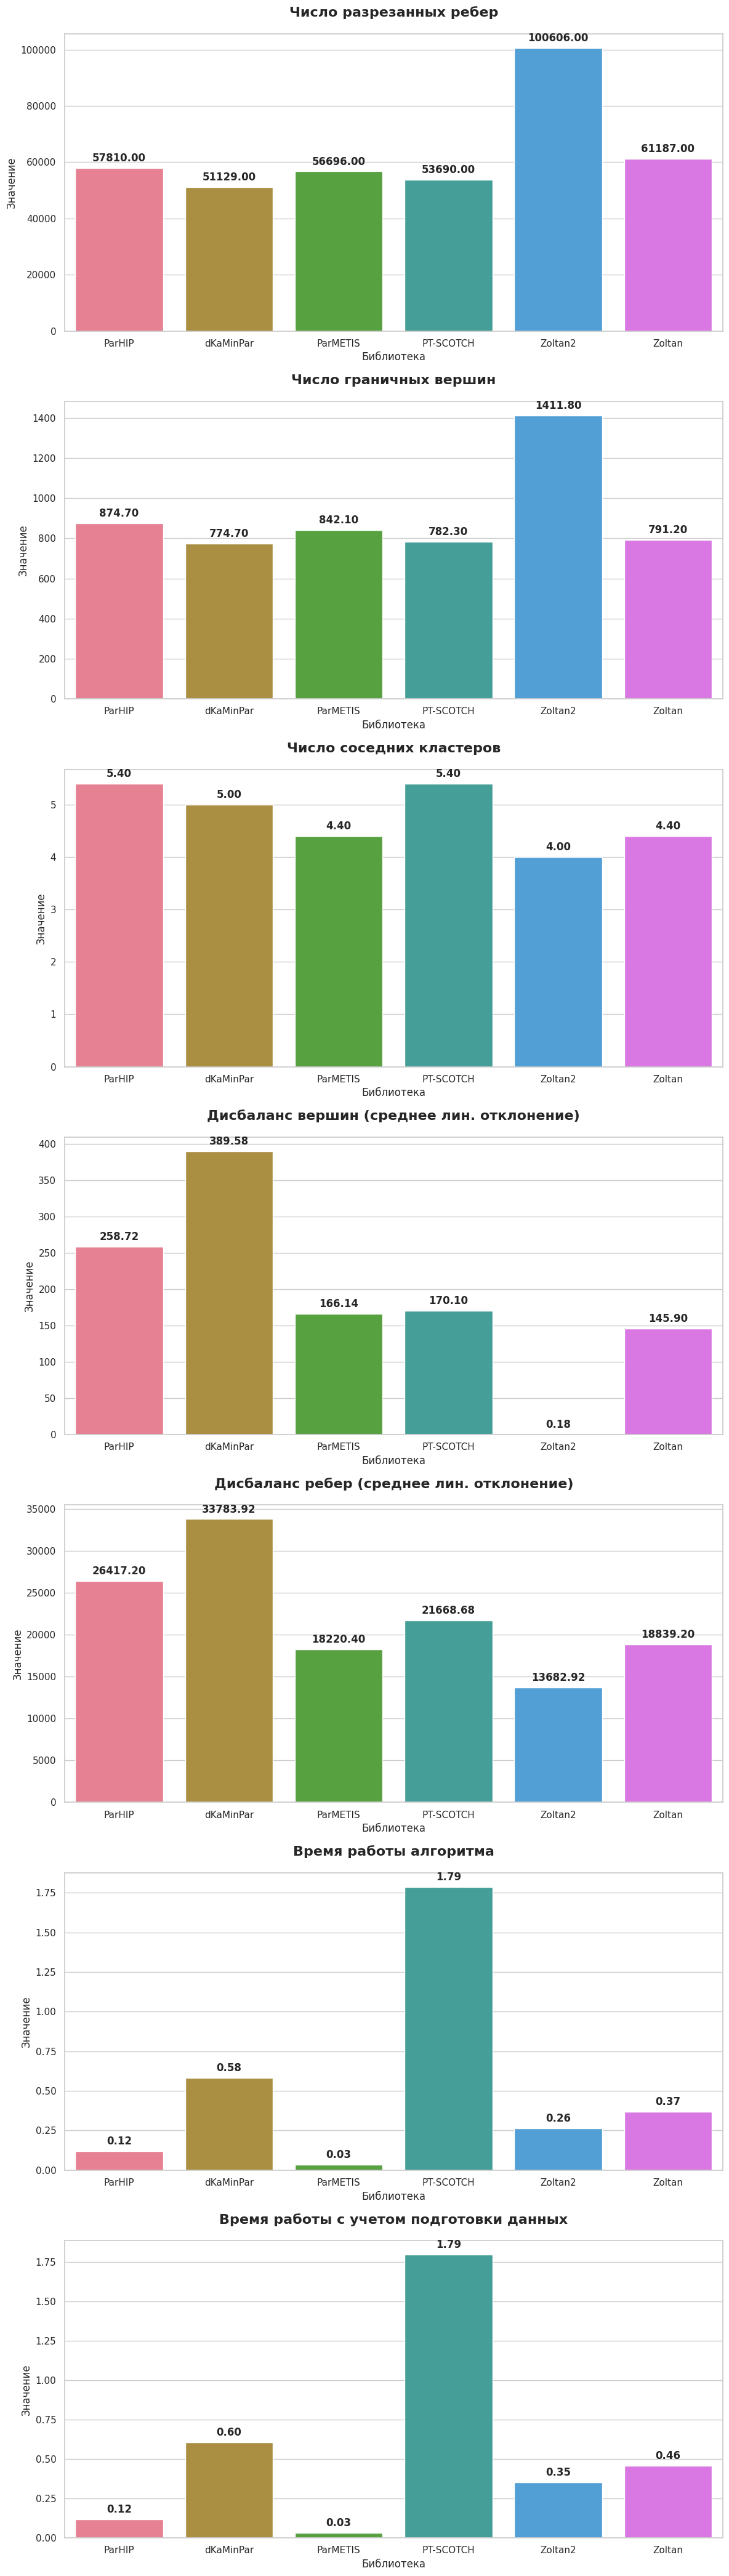

In [ ]:
unique_libs = df.index.unique()
colors = sns.color_palette("husl", len(unique_libs)) # Можно выбрать "tab10", "Set2" или "husl"
lib_palette = dict(zip(unique_libs, colors))

# 2. Настройка сетки графиков
sns.set(style="whitegrid")
fig, axes = plt.subplots(len(plots), 1, figsize=(12, 6 * len(plots)))

for i, (col, title) in enumerate(plots):
    ax = axes[i]

    # Строим график, передавая фиксированную палитру через параметр palette
    # Параметр hue гарантирует, что цвет привязан к имени индекса
    sns.barplot(x=df.index, y=df[col], ax=ax, palette=lib_palette, hue=df.index, legend=False)

    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    ax.set_ylabel('Значение')
    ax.set_xlabel('Библиотека')

    # Добавляем числа над столбцами
    for p in ax.patches:
        height = p.get_height()
        if pd.isna(height): height = 0
        ax.annotate(f'{height:.2f}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=12, fontweight='bold', xytext=(0, 5),
                    textcoords='offset points')

plt.tight_layout()
plt.show()